# ДЗ №3. VP-SDE диффузия на датасете «звёздочка»



In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

## 1. Датасет



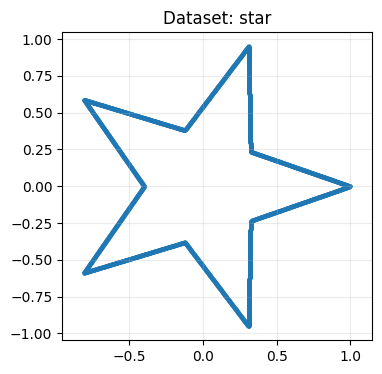

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=5000, center=(0, 0)):
    vertices = []
    angle_step = np.pi / n_spikes

    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])

    vertices.append(vertices[0])
    vertices = np.array(vertices)
    sampled_points = []
    samples_per_edge = max(1, n_samples // (len(vertices) - 1))

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]
        for t in np.linspace(0, 1, samples_per_edge, endpoint=False):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points[:n_samples], dtype=np.float32)


seed_everything(123)
star = generate_star(n_samples=5000)

plt.figure(figsize=(4, 4))
plt.scatter(star[:, 0], star[:, 1], s=3)
plt.title("Dataset: star")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.show()

## 2. Формулы VP-SDE

Для VP-SDE прямой процесс задаётся так:

$$
dx = -\frac{1}{2}\beta(t)x\,dt + \sqrt{\beta(t)}\,dw(t).
$$

Из этого получается удобная формула для зашумления точки сразу в момент времени $t$:

$$
x_t = \alpha(t)x_0 + \sigma(t)z, \quad z \sim \mathcal{N}(0, I),
$$

где

$$
\alpha^2(t)=\exp\left(-\int_0^t \beta(s)\,ds\right),
\quad
\sigma^2(t)=1-\alpha^2(t).
$$

Используем denoising-параметризацию: сеть предсказывает шум $z$. При сэмплировании score восстанавливается так:

$$
s_\theta(x_t,t) \approx -\frac{\varepsilon_\theta(x_t,t)}{\sigma(t)}.
$$


In [3]:
class Config:
    beta_min = 0.1
    beta_max = 20.0
    cosine_s = 0.008

    lr = 2e-3
    epochs = 300
    batch_size = 512
    hidden_dim = 128
    num_timesteps = 250
    data_samples = 5000

    t_eps = 1e-4
    t_max_cosine = 0.99


def vp_alpha_sigma(t, config, schedule):
    if schedule == "linear":
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        alpha2 = torch.exp(-int_beta)
    elif schedule == "cosine":
        s = config.cosine_s
        u = (t + s) / (1 + s) * math.pi / 2
        u0 = s / (1 + s) * math.pi / 2
        alpha2 = (torch.cos(u) / math.cos(u0)) ** 2
        alpha2 = torch.clamp(alpha2, min=1e-6, max=0.999999)
    else:
        raise ValueError(schedule)

    sigma2 = 1.0 - alpha2
    alpha = torch.sqrt(alpha2)
    sigma = torch.sqrt(torch.clamp(sigma2, min=1e-8))
    return alpha, sigma


def vp_beta(t, config, schedule):
    if schedule == "linear":
        return config.beta_min + (config.beta_max - config.beta_min) * t
    elif schedule == "cosine":
        s = config.cosine_s
        u = (t + s) / (1 + s) * math.pi / 2
        beta = math.pi / (1 + s) * torch.tan(u)
        # У косинусного расписания beta резко растёт около t=1,
        # поэтому для численной устойчивости ограничиваю значение.
        return torch.clamp(beta, min=config.beta_min, max=80.0)
    else:
        raise ValueError(schedule)

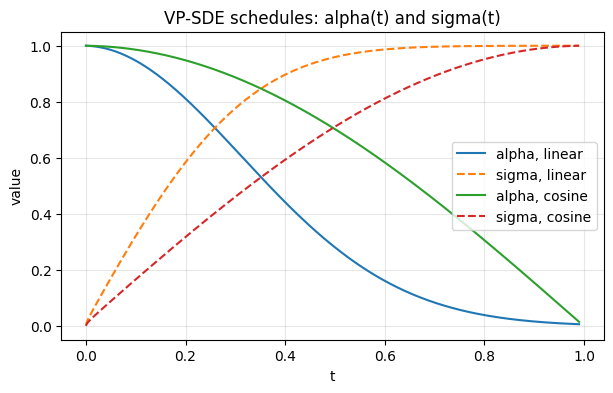

In [4]:
config = Config()
t_grid = torch.linspace(config.t_eps, 0.99, 500).view(-1, 1)

plt.figure(figsize=(7, 4))
for schedule in ["linear", "cosine"]:
    alpha, sigma = vp_alpha_sigma(t_grid, config, schedule)
    plt.plot(t_grid.numpy(), alpha.numpy(), label=f"alpha, {schedule}")
    plt.plot(t_grid.numpy(), sigma.numpy(), "--", label=f"sigma, {schedule}")

plt.title("VP-SDE schedules: alpha(t) and sigma(t)")
plt.xlabel("t")
plt.ylabel("value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3. Модель

Архитектура оставлена простой: MLP для двумерных точек и sinusoidal embedding для времени. На выходе сеть выдаёт двумерный вектор — оценку шума z.

In [5]:
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        half_dim = hidden_dim // 2
        freqs = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), half_dim))
        self.register_buffer("freqs", freqs)

    def forward(self, t):
        x = t * self.freqs[None, :] * 2 * math.pi
        return torch.cat([torch.sin(x), torch.cos(x)], dim=1)


class ScoreModel(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()

        self.time_embed = nn.Sequential(
            TimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        return self.net(torch.cat([x, t_embed], dim=1))

## 4. Перевзвешивание лосса

Проверил четыре варианта:

1. uniform — обычный MSE без дополнительного веса;
2. sigma2 — вес $\sigma^2(t)$, то есть больше внимания большим шумам;
3. sqrt_clipped_snr — мягкий вариант SNR-веса;
4. clipped_snr — SNR-вес с ограничением.

SNR-вес нельзя брать напрямую как $\alpha^2(t) / \sigma^2(t)$, потому что около одного из концов он может сильно взрываться. Поэтому в коде используется clamp и нормализация веса по батчу.


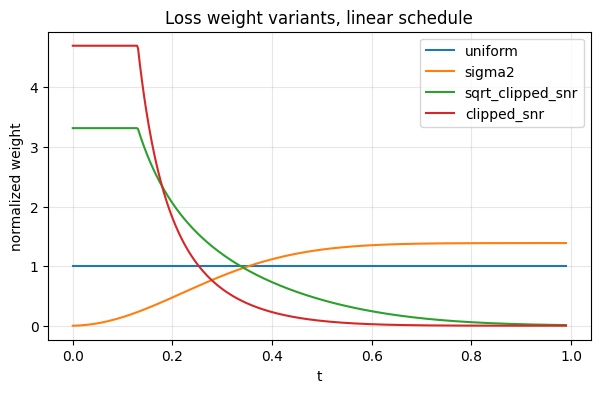

In [7]:
def loss_weight(t, alpha, sigma, variant):
    if variant == "uniform":
        w = torch.ones_like(t)
    elif variant == "sigma2":
        w = sigma ** 2
    elif variant == "sqrt_clipped_snr":
        snr = (alpha ** 2) / (sigma ** 2 + 1e-6)
        w = torch.sqrt(torch.clamp(snr, min=0.0, max=5.0))
    elif variant == "clipped_snr":
        snr = (alpha ** 2) / (sigma ** 2 + 1e-6)
        w = torch.clamp(snr, min=0.0, max=5.0)
    else:
        raise ValueError(variant)

    return w / (w.mean().detach() + 1e-8)


def plot_weights(schedule="linear"):
    config = Config()
    t = torch.linspace(config.t_eps, 0.99, 500).view(-1, 1)
    alpha, sigma = vp_alpha_sigma(t, config, schedule)

    plt.figure(figsize=(7, 4))
    for variant in ["uniform", "sigma2", "sqrt_clipped_snr", "clipped_snr"]:
        w = loss_weight(t, alpha, sigma, variant)
        plt.plot(t.numpy(), w.numpy(), label=variant)

    plt.title(f"Loss weight variants, {schedule} schedule")
    plt.xlabel("t")
    plt.ylabel("normalized weight")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


plot_weights("linear")

## 5. Обучение и сэмплирование

Forward:

$$
x_t = \alpha(t)x_0 + \sigma(t)z.
$$

Loss:

$$
L = w(t)\left\|\varepsilon_\theta(x_t,t)-z\right\|^2.
$$

Sampling идёт из $x_T \sim \mathcal{N}(0, I)$ назад к $t=0$. Для reverse VP-SDE используется шаг Эйлера-Маруямы:

$$
x_{t-\Delta t}
=
x_t
+
\left(
\frac{1}{2}\beta(t)x_t
+
\beta(t)s_\theta(x_t,t)
\right)\Delta t
+
\sqrt{\beta(t)\Delta t}\,z.
$$

Здесь

$$
s_\theta(x_t,t) = -\frac{\varepsilon_\theta(x_t,t)}{\sigma(t)}.
$$


In [6]:
class VPTrainer:
    def __init__(self, config, schedule="linear", weight_variant="uniform", seed=123):
        seed_everything(seed)
        self.config = config
        self.schedule = schedule
        self.weight_variant = weight_variant
        self.device = DEVICE

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config.hidden_dim).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.losses = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        total_count = 0

        t_max = 1.0 if self.schedule == "linear" else self.config.t_max_cosine

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            batch_size = batch.shape[0]

            t = self.config.t_eps + (t_max - self.config.t_eps) * torch.rand(batch_size, 1, device=self.device)
            alpha, sigma = vp_alpha_sigma(t, self.config, self.schedule)

            z = torch.randn_like(batch)
            x_t = alpha * batch + sigma * z

            pred_z = self.model(x_t, t)
            mse = ((pred_z - z) ** 2).sum(dim=1, keepdim=True)
            w = loss_weight(t, alpha, sigma, self.weight_variant)
            loss = (w * mse).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * batch_size
            total_count += batch_size

        epoch_loss = total_loss / total_count
        self.losses.append(epoch_loss)
        return epoch_loss

    def run(self):
        for epoch in range(self.config.epochs):
            self.train_epoch()
        return self.losses


@torch.no_grad()
def sample_vp_sde(model, config, schedule="linear", num_samples=1000):
    model.eval()
    device = next(model.parameters()).device

    t_max = 1.0 if schedule == "linear" else config.t_max_cosine
    dt = (t_max - config.t_eps) / config.num_timesteps

    x = torch.randn(num_samples, 2, device=device)

    for i in range(config.num_timesteps):
        t_value = t_max - i * dt
        t_value = max(t_value, config.t_eps)
        t = torch.full((num_samples, 1), t_value, device=device)

        alpha, sigma = vp_alpha_sigma(t, config, schedule)
        beta = vp_beta(t, config, schedule)

        pred_z = model(x, t)
        score = -pred_z / (sigma + 1e-6)

        drift = (0.5 * beta * x + beta * score) * dt
        diffusion = torch.sqrt(beta * dt) * torch.randn_like(x)
        x = x + drift + diffusion

    return x.cpu().numpy()

## 6. Запуск экспериментов

Ниже запускаются 8 экспериментов: 2 расписания х 4 варианта весов. На CPU это занимает несколько минут. Для воспроизводимости seed фиксирован


In [8]:
def run_experiment(schedule, weight_variant, seed=123):
    config = Config()
    trainer = VPTrainer(config, schedule=schedule, weight_variant=weight_variant, seed=seed)
    losses = trainer.run()
    samples = sample_vp_sde(trainer.model, config, schedule=schedule, num_samples=1000)
    return {
        "schedule": schedule,
        "weight_variant": weight_variant,
        "losses": losses,
        "samples": samples,
    }


schedules = ["linear", "cosine"]
weight_variants = ["uniform", "sigma2", "sqrt_clipped_snr", "clipped_snr"]

results = {}
for schedule in schedules:
    for weight_variant in weight_variants:
        print(f"train: {schedule:6s} | {weight_variant}")
        results[(schedule, weight_variant)] = run_experiment(schedule, weight_variant)
        print(f"final loss = {results[(schedule, weight_variant)]['losses'][-1]:.4f}")

train: linear | uniform
final loss = 0.3704
train: linear | sigma2
final loss = 0.0998
train: linear | sqrt_clipped_snr
final loss = 0.9461
train: linear | clipped_snr
final loss = 1.1364
train: cosine | uniform
final loss = 0.6856
train: cosine | sigma2
final loss = 0.2271
train: cosine | sqrt_clipped_snr
final loss = 0.9714
train: cosine | clipped_snr
final loss = 1.1372


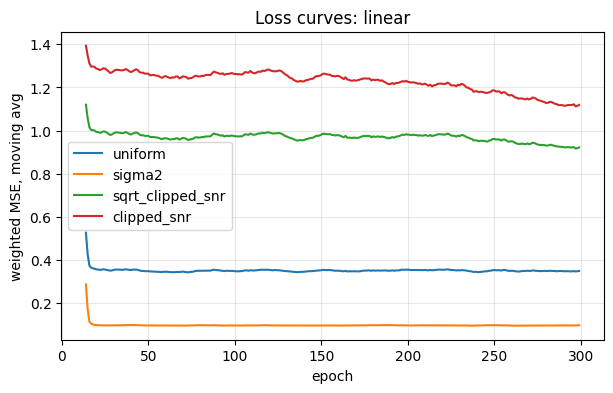

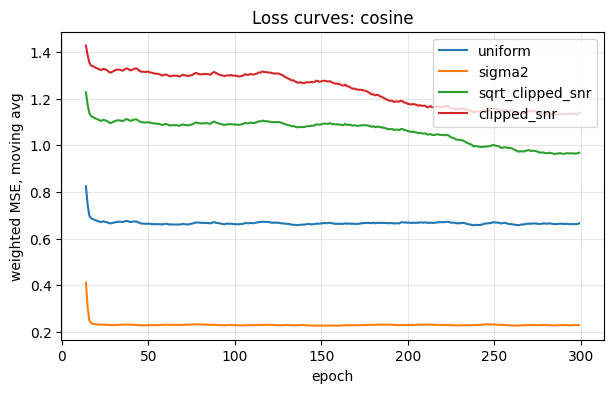

In [9]:
def moving_average(values, window=15):
    values = np.asarray(values)
    if len(values) < window:
        return np.arange(len(values)), values
    kernel = np.ones(window) / window
    ma = np.convolve(values, kernel, mode="valid")
    x = np.arange(len(ma)) + window - 1
    return x, ma


for schedule in schedules:
    plt.figure(figsize=(7, 4))
    for weight_variant in weight_variants:
        losses = results[(schedule, weight_variant)]["losses"]
        x, y = moving_average(losses)
        plt.plot(x, y, label=weight_variant)

    plt.title(f"Loss curves: {schedule}")
    plt.xlabel("epoch")
    plt.ylabel("weighted MSE, moving avg")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

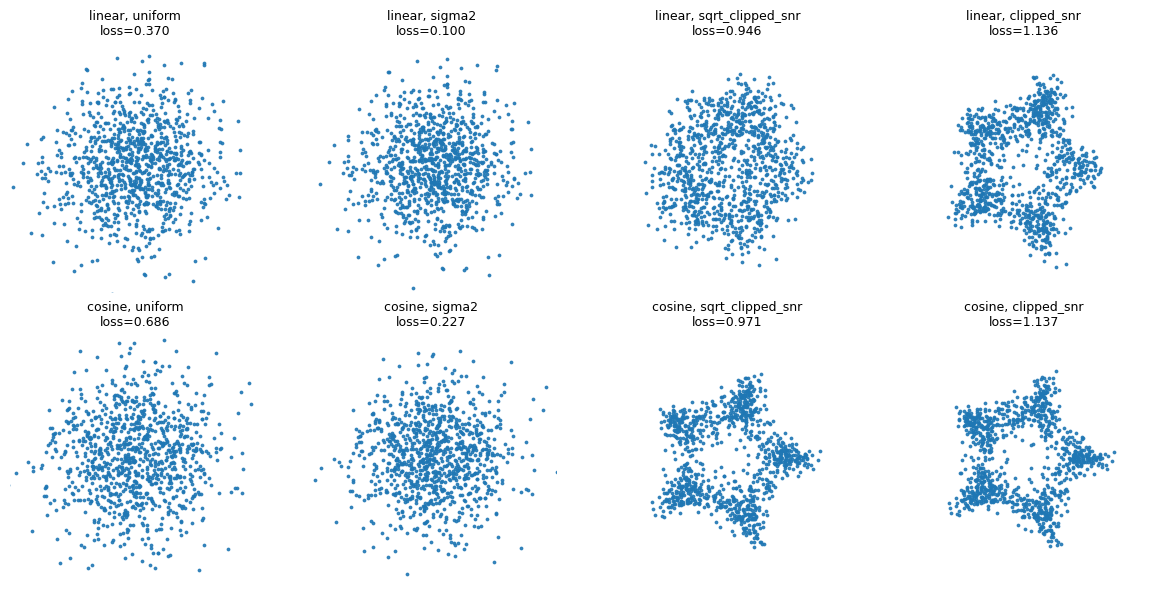

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, schedule in enumerate(schedules):
    for j, weight_variant in enumerate(weight_variants):
        samples = results[(schedule, weight_variant)]["samples"]
        loss = results[(schedule, weight_variant)]["losses"][-1]

        ax = axes[i, j]
        ax.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.85)
        ax.set_title(f"{schedule}, {weight_variant}\nloss={loss:.3f}", fontsize=9)
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect("equal")
        ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Вывод

По результатам видно, что сама VP-SDE работает: при удачном перезвешивании получается не просто облако точек, а форма звезды.

Обычный uniform-loss и вес sigma2 в этой задаче дали более размытые выборки. При этом у sigma2 численно loss меньше, но это не значит, что модель лучше: величины loss между разными весами напрямую сравнивать нельзя, потому что сама функция потерь меняется. Визуально sigma2 уделяет слишком много внимания большим шумам и хуже собирает тонкий контур звезды.

Лучше всего визуально сработал clipped_snr. Это логично: SNR-вес сильнее обращает внимание на малые и средние уровни шума, где модель должна восстановить именно геометрию контура. При этом сырой SNR не используется, потому что $\alpha^2(t) / \sigma^2(t)$ может взрываться. В коде стоит clamp и нормализация по батчу.

Сравнение расписаний:

- linear schedule более простой и устойчивый
- cosine schedule с clipped_snr дал чуть более собранную звезду в этом запуске
- для cosine пришлось ограничить верхнее время t_max=0.99 и зажать beta, потому что около t=1 косинусное расписание становится слишком резким

Итог: для этой маленькой 2D-задачи лучшая комбинация из проверенных — VP-SDE + cosine schedule + clipped SNR weight. Линейное расписание тоже рабочее, но при одинаковом числе эпох форма получается чуть менее аккуратной
